#Environment setup

In [1]:
# Importing the nececassy libraries
import pandas as pd
import numpy as np,random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf



In [2]:
#Theme for plots
sns. set_theme(style='whitegrid')

In [3]:

# Reading the file into a Pandas dataframe
df_raw = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#Making a copy and using that for EDA
df=df_raw.copy()


#EDA

In [ ]:
# Dataset metadata
#Check the why for this and then add

##Smoke Tests

In [4]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Monthly charges and total charges columns look too multicolinear. Check the connection a bit and drop a column if it's too similar.

In [5]:
df.shape

#Number of rows and columns
rows=df.shape[0]
cols= df.shape[1]
print(f"Dataset has {rows} rows and {cols} columns")

Dataset has 7043 rows and 21 columns


In [6]:
#Checking the datatypes
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Total charges is an object dtype, which seems wrong. Have to change the data type into a numeric type.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#Checking empty strings in categorical columns, by making a new dataframe
obj_cols= df.select_dtypes(include='object').columns
(df[obj_cols] == '').sum()


,0
customerID,0
gender,0
Partner,0
Dependents,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


From the above explorations, we can identify that the 'TotalCharges' column appears to be a column of data type,'object'. However since total charges should be a numeric column, the data type is converted in the follwoing manner to cotinue exploration and to stop it from affecting the pipeline.

In [9]:
#Changing the 'TotalCharge' column, datatype.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [10]:
#Checking the new total charges column
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
# Find missing values in the numeric columns
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


A simple null check proves that, the total charges column after it was coverted to a numeric column contains 11 values which has been replaced with NaN while conversion, therefore the column contains 11 mismatched values.

In [12]:
# Descriptions for the numerical features
#df.describe(include='all').T
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
# Descriptions for the categorical features
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [14]:
#Numerical column list
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_columns)
print(" ")

#categorical column list
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()
non_numeric_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
 


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

Plotting the traget distribution to check class imbalances.

In [15]:
# Value distribution of traget variable
print(df['Churn'].value_counts(normalize=True))
df['Churn'].value_counts()



Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


,count
Churn,
No,5174
Yes,1869


Text(0.5, 1.0, 'Churn distribution')

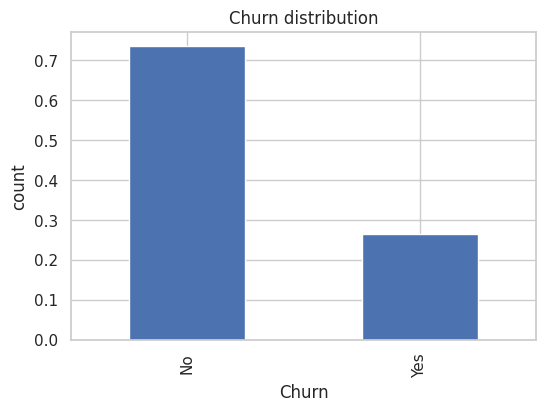

In [16]:

#Plotting the target distriution
plt.figure(figsize=(6, 4))
ax = df['Churn'].value_counts(normalize=True).plot.bar()
ax.set_ylabel('count'); ax.set_title('Churn distribution')

The above plot shows the class imbalanace of the traget distribution, therefore normalising must be done to avoid bias in the modelling phase

## Univariate Analysis


*   Tenure : How many months the customer has stayed with the company
*   Churn: Whether the customer churned or not in the past month (Yes or No)

### Numerical features

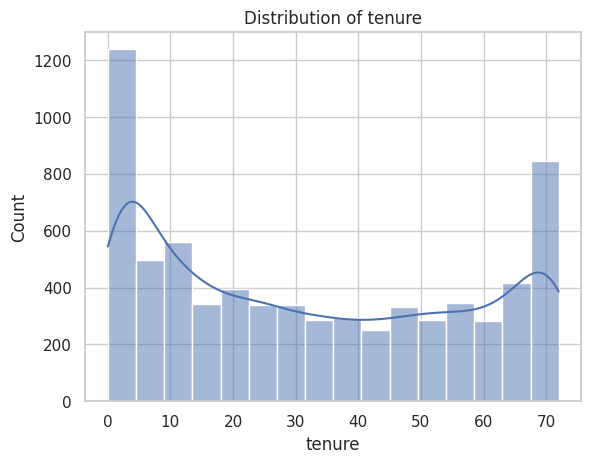

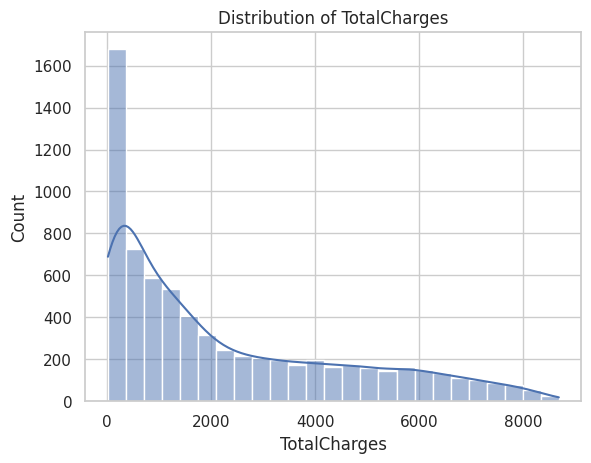

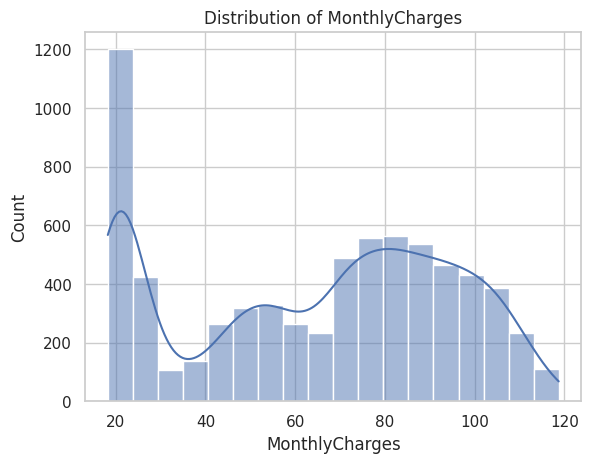

In [ ]:
#Plotting the numerical columns such as tenure, total charges, monthly charges, senior citizen
for col in ['tenure', 'TotalCharges', 'MonthlyCharges']:
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()



**Observations for the numerical features.**
1. Tenure
  *   Is left skewed (has a small right skew as well)
  *   Most people are new customers
  *   Rise between 60- 70 years

2. total charges
  *   Is left skewed
  *   Majority pays less that 2,000
  *   Has a moderate spread

3. monthly charges
  *   Is marginally left skewed
  *   Has a large spread, possible outliers
  






- Senior citizen feature is highly imbalanced, only a minority are seniors.

###Outlier and summary stats

Text(0.5, 1.0, 'Monthly charges')

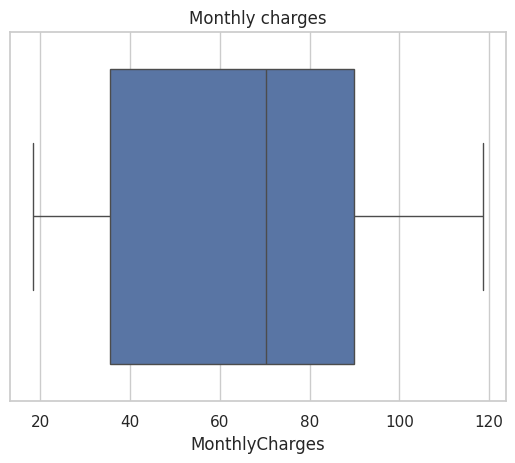

In [ ]:
sns.boxplot(x=df['MonthlyCharges'])
plt.title(f'Monthly charges')


Text(0.5, 1.0, 'Total charges')

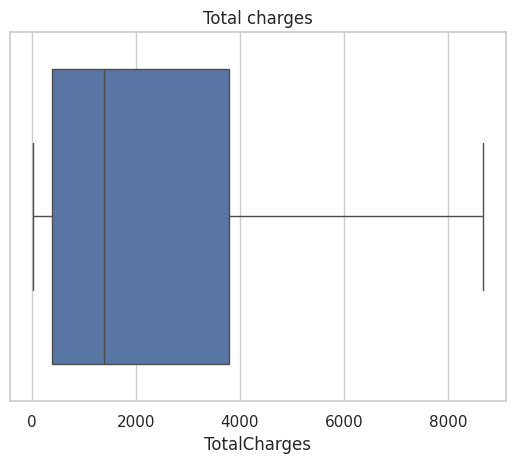

In [ ]:
sns.boxplot(x=df['TotalCharges'])
plt.title(f'Total charges')

Text(0.5, 1.0, 'Tenure')

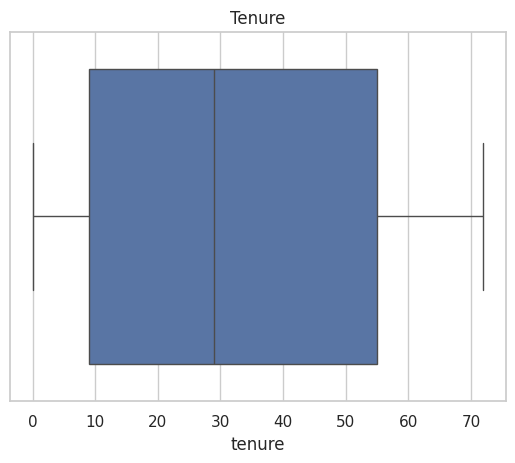

In [ ]:
sns.boxplot(x=df['tenure'])
plt.title(f'Tenure')

In [ ]:
#IQR method for outlier identification
def outlier_summary(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.50 * IQR
    upper = Q3 + 1.50 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

for col in ['MonthlyCharges','TotalCharges','tenure']:
    print(f'{col} = {outlier_summary(col)}')

MonthlyCharges = 0
TotalCharges = 0
tenure = 0


###Categorical features

In [ ]:
#Plotting the categorical features to check the distribution
non_numeric_columns

#Non numeric columns without the ID and Churn columns for plotting
non_numeric_columns.remove('customerID')
non_numeric_columns.remove('Churn')
non_numeric_columns



['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [ ]:
df_plot = df.copy()
df_plot['SeniorCitizen'] = df_plot['SeniorCitizen'].map({0: "No", 1: "Yes"})



Since the SeniorCitizen column was of dtype = numeric, it was mapped to 0 and 1 for plotting temporarily.

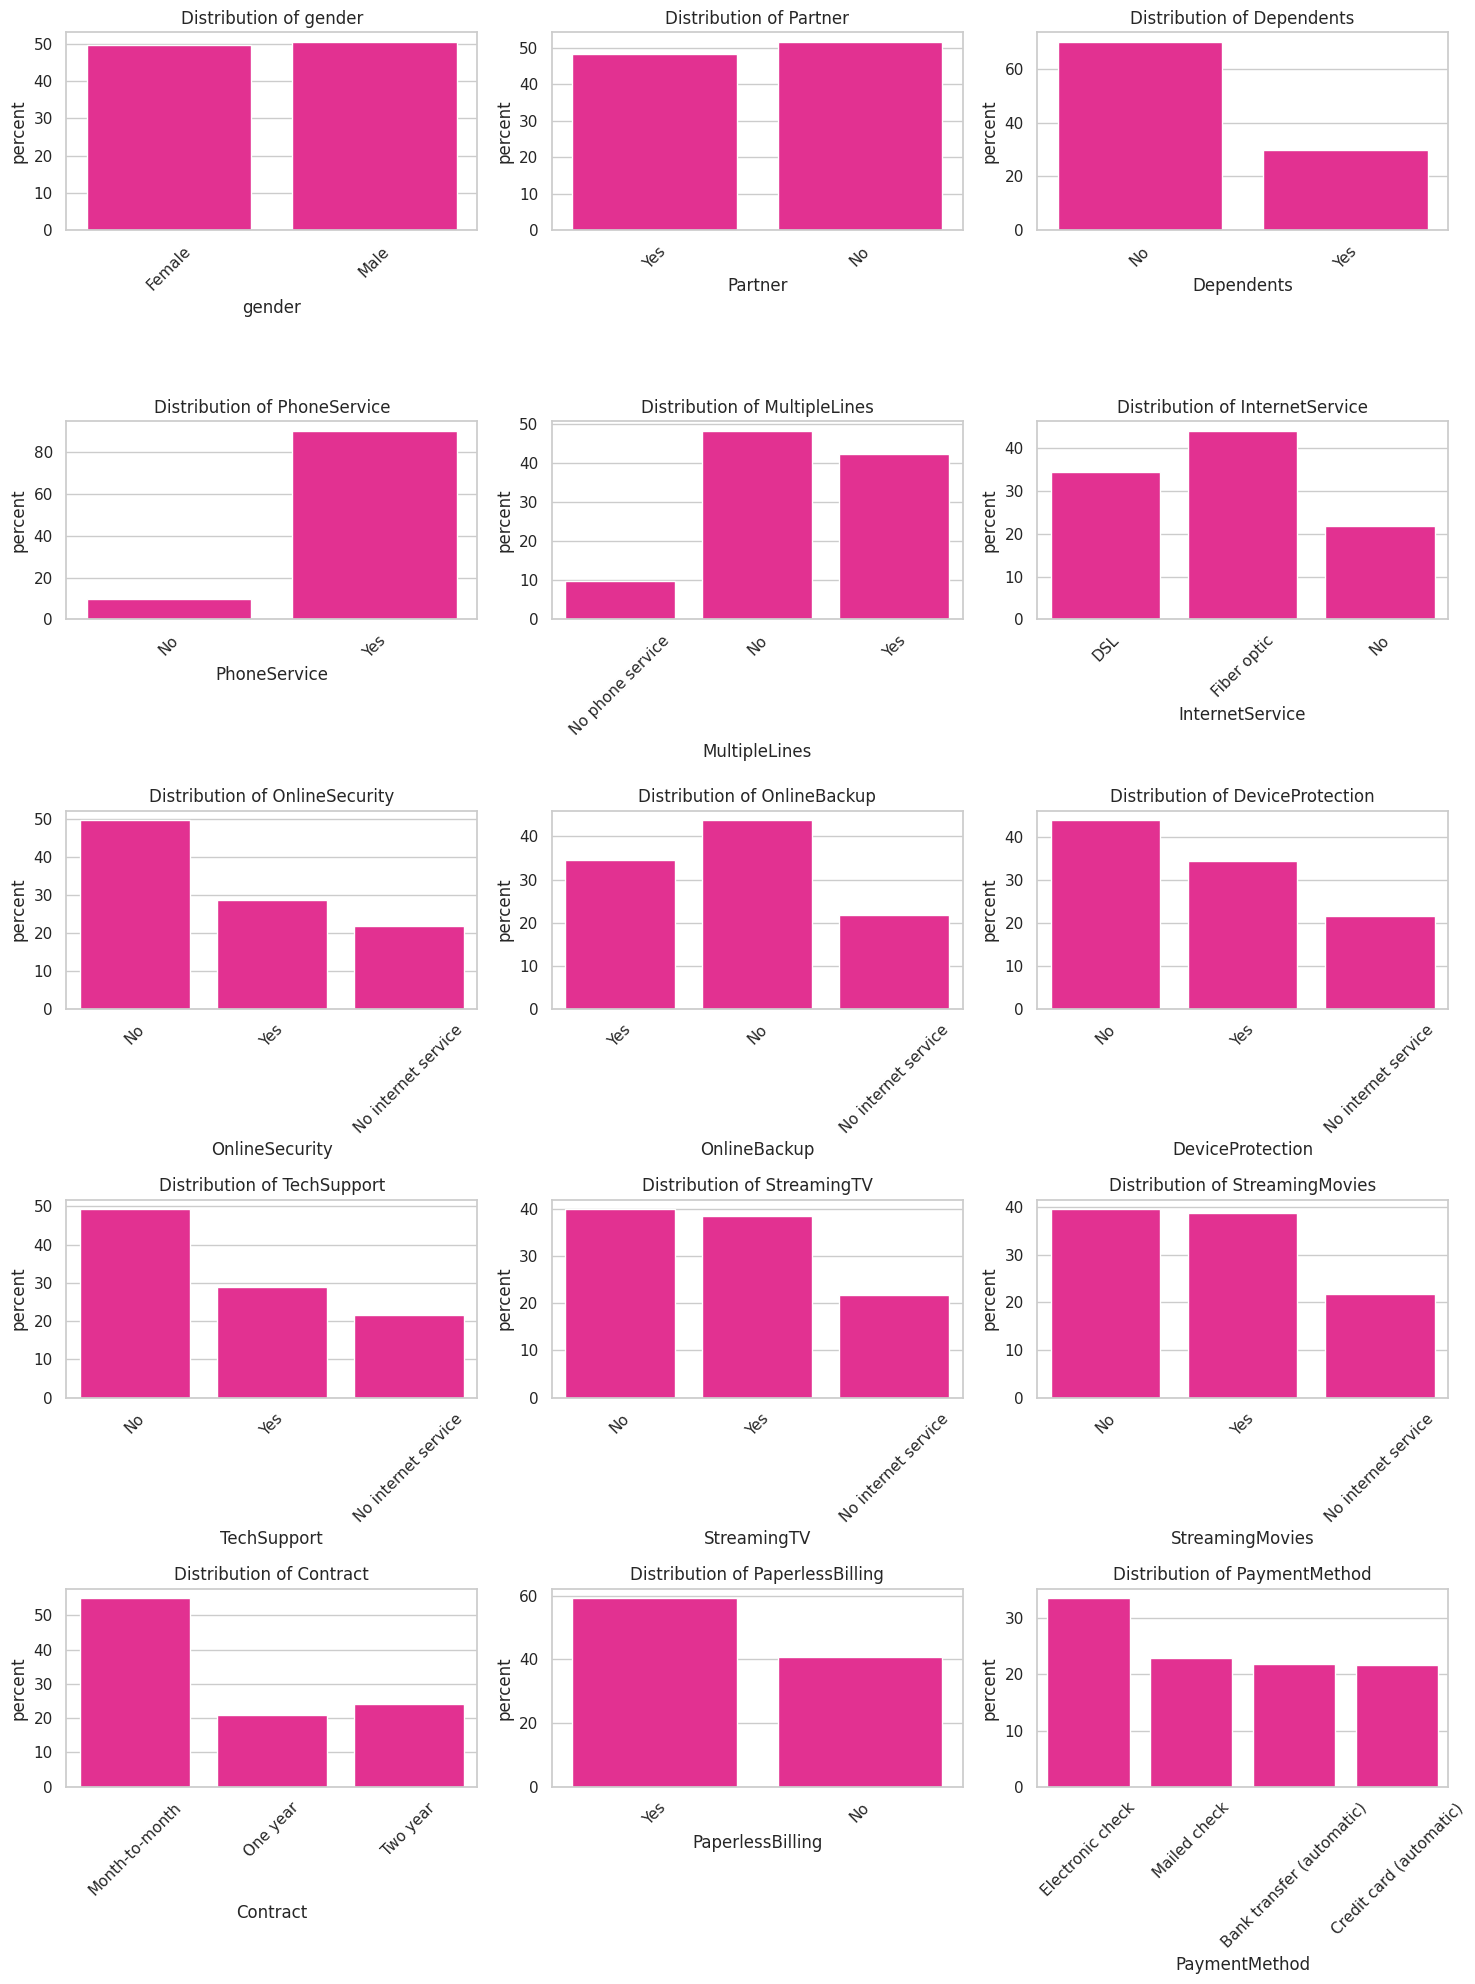

In [ ]:

cols_per_row = 3
num_plots = len(non_numeric_columns)
rows = (num_plots + cols_per_row - 1) // cols_per_row

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 4))
axes = axes.flatten()  # Flatten in case of multiple rows

# Plot each column
for i, col in enumerate(non_numeric_columns):
    sns.countplot(data=df, x=col, ax=axes[i], stat='percent', color='deeppink')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Senior Citizen Distribution')

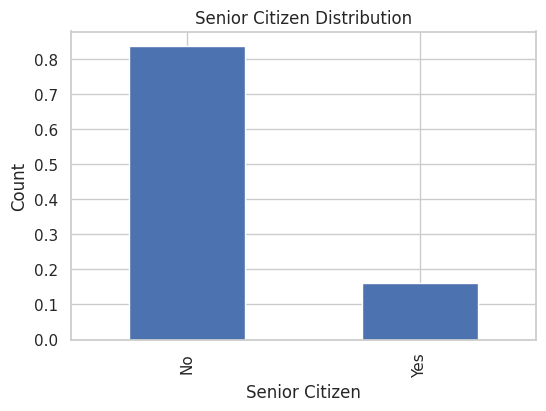

In [ ]:
#The other numeric column, but is mostly should be categorical, mapped for plotting.
plt.figure(figsize=(6, 4))
ax = df_plot['SeniorCitizen'].value_counts(normalize=True).plot.bar()
ax.set_ylabel('Count')
ax.set_xlabel('Senior Citizen')
ax.set_title('Senior Citizen Distribution')


**Observations for categorical features**


*   Almost to no gender imbalance, a tiny proportion more males
* Big imbalance for senior citizens, where only ~ 0.15% being seniors.
- Partner column is slightly imbalanced to have more people who do not have partners
- Dependants feature is imbalanced, majority do not have family with them
- Phone service is largely imbalanced, where there's a small group without service, possibly seniors.
- Majority have one phone line, but a close number to that also has multiple lines and only ~10% without neither.
- Service type is mostly fiber optics with DSL coming close. Has a large portion (~20%) without internet.
- Almost half do not have online secuirity while about 30% only having it.
- Most people do not have online backups
- Almost ~50% do not have device protection either, with only ~30% ahving it and the rest has no internet.
- ~50 % do not receive tech support.
- Majority has a monthly contract.
- More than half of the people use paperless billing.
- Most people opt for electronic check (since ~60 % has paperless billing), the others has been equally ditributed with the rest of the modes.
- Out of the people with internet service, almsot equal numbers stream movies and t.v.
- With a close margin, people do not stream t.v or movies of the proportion whose has interent service.
- Tech support, device protection and online secuirty follows similar patterns for classes, somewhat close in value ranges as well.
- ~25 % does not has internet service, therefore not eligible with streaming or other online services.





## Bivariate Analysis
- To explore how each feature impacts 'churn'
- To find whihc features contributes to higher churn

###Categorical features vs. Churn
Will display one plot and explanations since that's more cleaner (though longer)

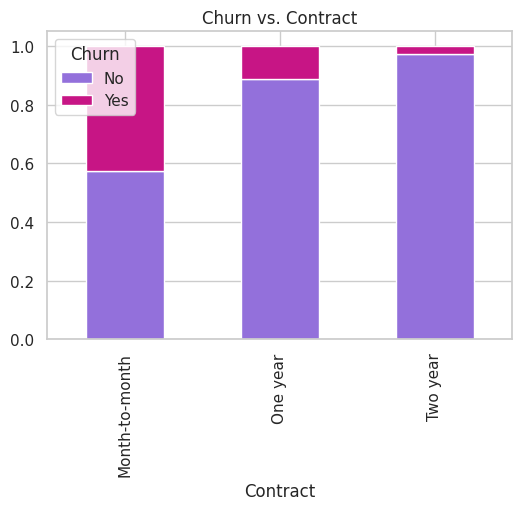

In [ ]:
# Contract vs. Churn
# Plotting a stacked bar plot for churn and contract
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', stacked=True, figsize=(6, 4), color=['mediumpurple', 'mediumvioletred'])

plt.title('Churn vs. Contract')
plt.show()


Text(0.5, 1.0, 'Internet service vs Churn')

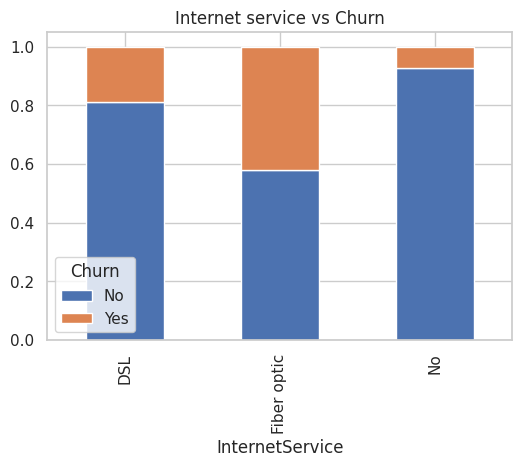

In [ ]:
#Bivariate between churn and internet service
pd.crosstab(df['InternetService'],df['Churn'], normalize='index').plot(kind='bar',stacked='true',figsize=(6,4))

plt.title('Internet service vs Churn')

Text(0.5, 1.0, 'Dependants vs Churn')

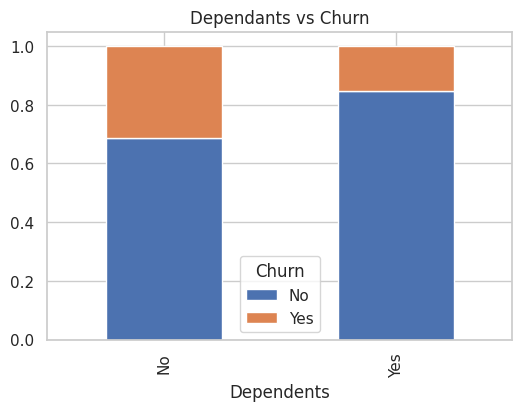

In [ ]:
#Bivariate between churn and dependants
pd.crosstab(df['Dependents'],df['Churn'], normalize='index').plot(kind='bar',stacked='true',figsize=(6,4))

plt.title('Dependants vs Churn')

Text(0.5, 1.0, 'Gender vs Churn')

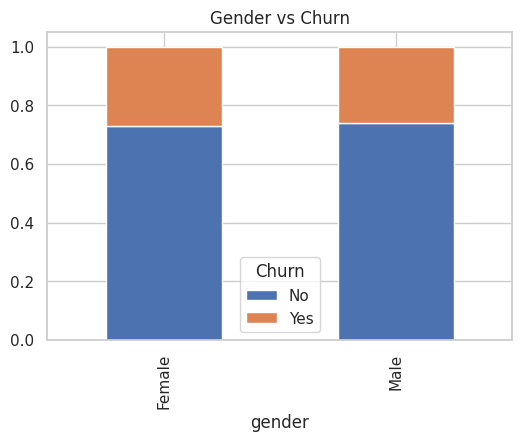

In [ ]:
#Bivariate between gender and churn
pd.crosstab(df['gender'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Gender vs Churn")

Text(0.5, 1.0, 'Partner vs Churn')

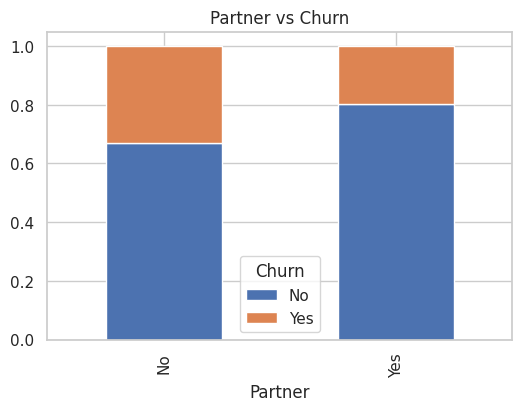

In [ ]:
#Bivariate between partner and churn
pd.crosstab(df['Partner'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Partner vs Churn")

Text(0.5, 1.0, 'Payment method vs Churn')

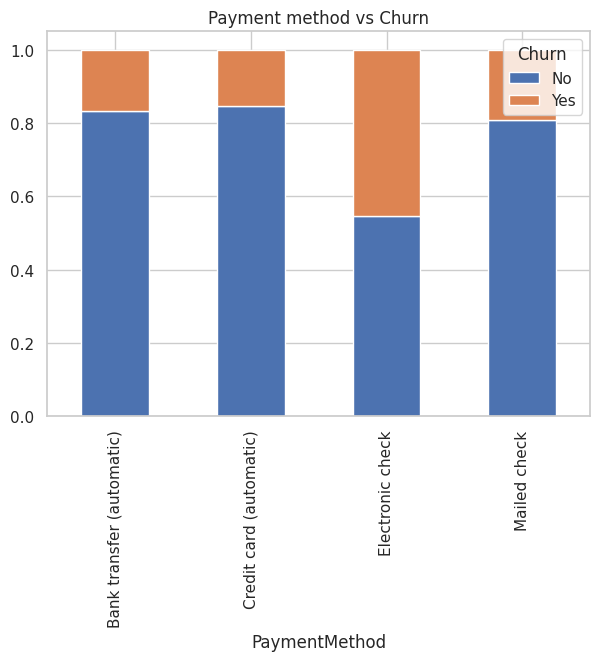

In [ ]:
#Bivariate between payment method and churn
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(7,5))

plt.title("Payment method vs Churn")

Text(0.5, 1.0, 'Paperless billing vs Churn')

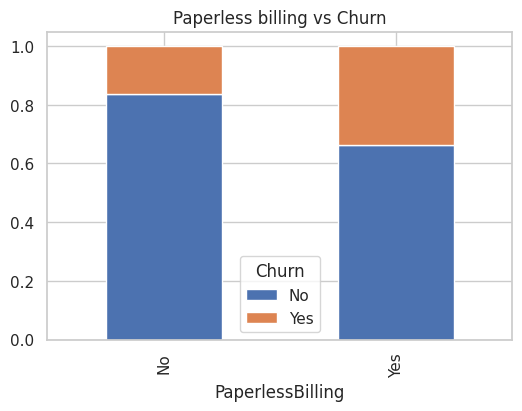

In [ ]:
# Churn and paperless billing
pd.crosstab(df['PaperlessBilling'],df['Churn'],normalize='index').plot(kind='bar',stacked='true',figsize=(6,4))

plt.title('Paperless billing vs Churn')

Text(0.5, 1.0, 'Phone service vs Churn')

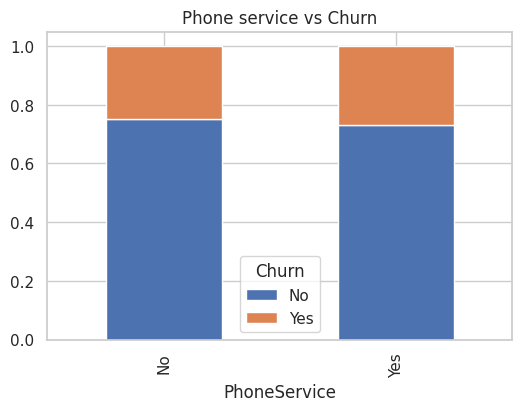

In [ ]:
#Bivariate between phone service and churn
pd.crosstab(df['PhoneService'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Phone service vs Churn")

Text(0.5, 1.0, 'Tech support vs Churn')

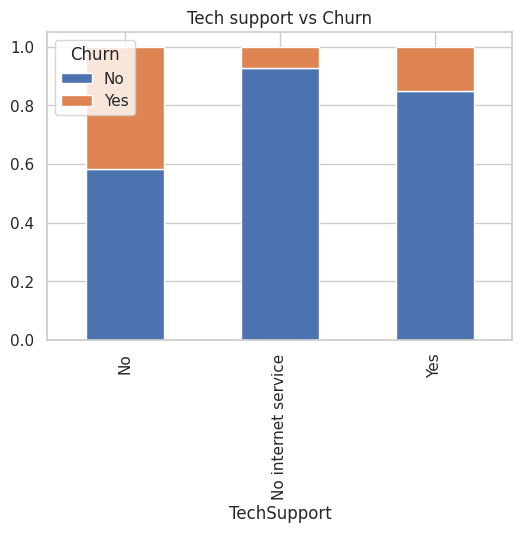

In [ ]:
#Bivariate between partner and churn
pd.crosstab(df['TechSupport'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Tech support vs Churn")

Text(0.5, 1.0, 'Streaming TV vs Churn')

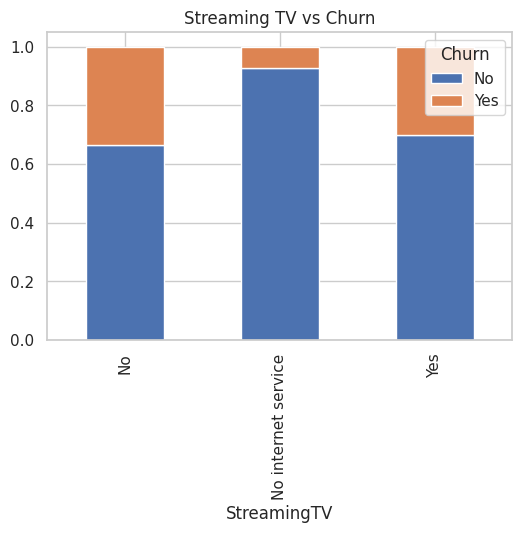

In [ ]:
#Bivariate between TV and churn
pd.crosstab(df['StreamingTV'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Streaming TV vs Churn")

Text(0.5, 1.0, 'Multiple lines vs Churn')

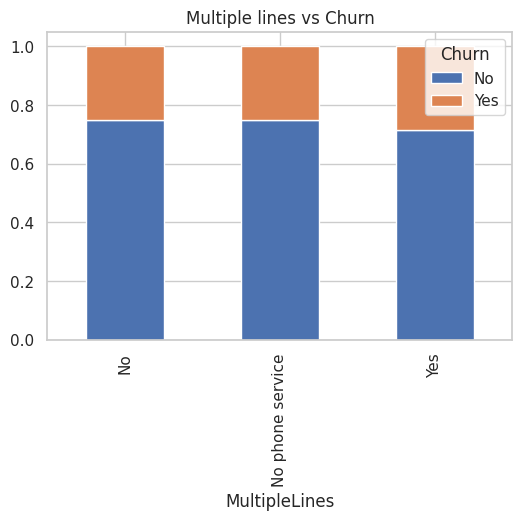

In [ ]:
#Bivariate between multiple lines and churn
pd.crosstab(df['MultipleLines'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Multiple lines vs Churn")

Text(0.5, 1.0, 'Online security vs Churn')

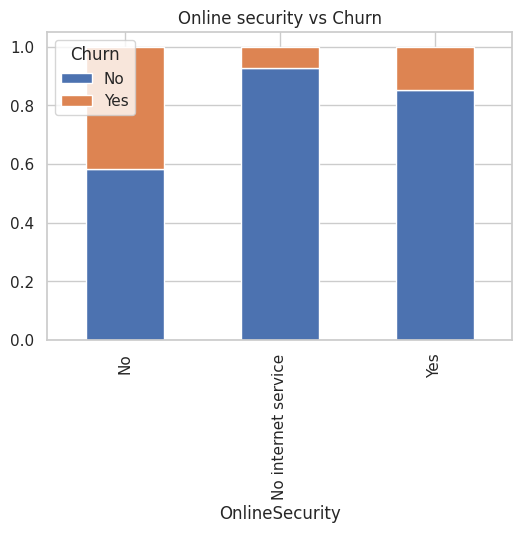

In [ ]:
#Bivariate between online security and churn
pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Online security vs Churn")

Text(0.5, 1.0, 'Device protection vs Churn')

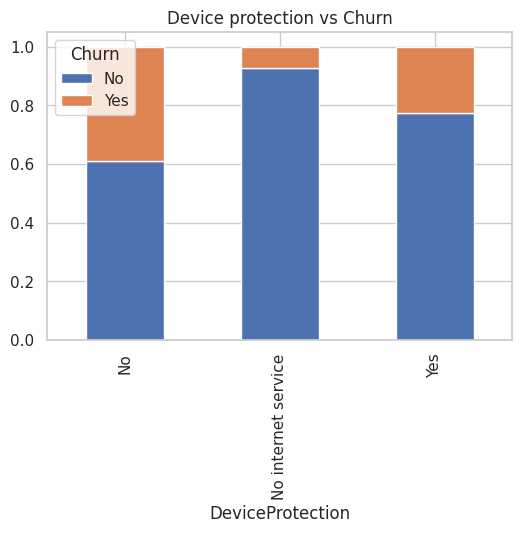

In [ ]:
#Bivariate between device protection and churn
pd.crosstab(df['DeviceProtection'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Device protection vs Churn")

Text(0.5, 1.0, 'Online backup vs Churn')

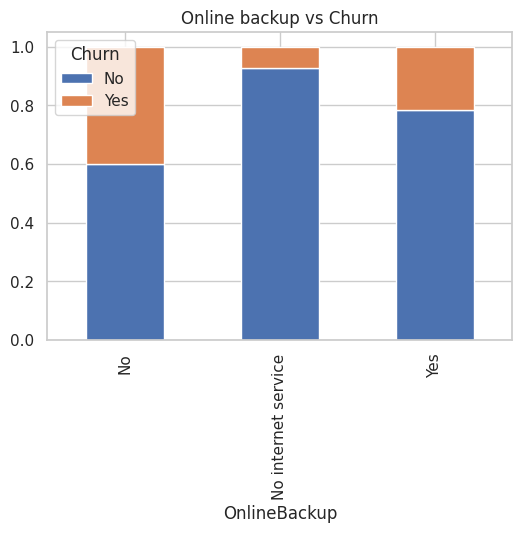

In [ ]:
#Bivariate between partner and churn
pd.crosstab(df['OnlineBackup'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Online backup vs Churn")

Text(0.5, 1.0, 'Streaming movies vs Churn')

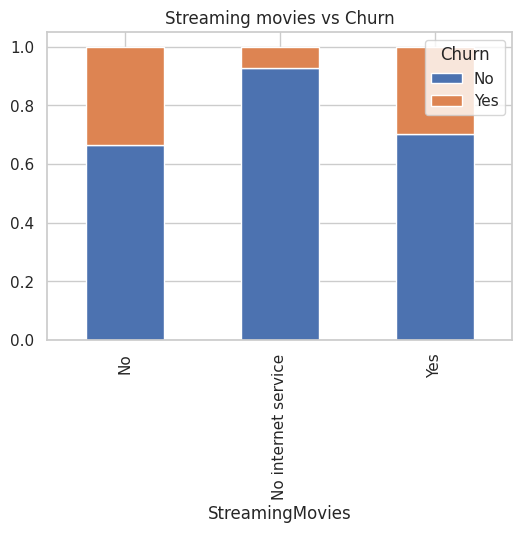

In [ ]:
#Bivariate between partner and churn
pd.crosstab(df['StreamingMovies'],df['Churn'],normalize='index').plot(kind='bar',stacked='true', figsize=(6,4))

plt.title("Streaming movies vs Churn")

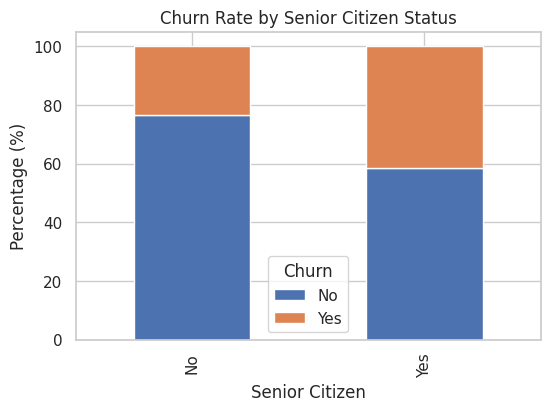

In [ ]:
#getting the percentages by churn
senior_pct = (
    df_plot.groupby('SeniorCitizen')['Churn']
           .value_counts(normalize=True)
           .unstack() * 100
)

#renaming the columns
senior_pct = senior_pct.rename(columns={0: "No Churn", 1: "Churn"})

# plotting
senior_pct.plot(kind='bar', stacked=True, figsize=(6,4))
plt.ylabel('Percentage (%)')
plt.xlabel('Senior Citizen')
plt.title('Churn Rate by Senior Citizen Status')
plt.legend(title='Churn')






###Numerical features vs. Churn
Will display one plot and explanations since that's more cleaner (though longer)

**!!! Add the other stacked bar plots and other plots for total and monthly charges plots besides the boxed plots.**

/tmp/ipython-input-3729183019.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(tenure_bin)['Churn']


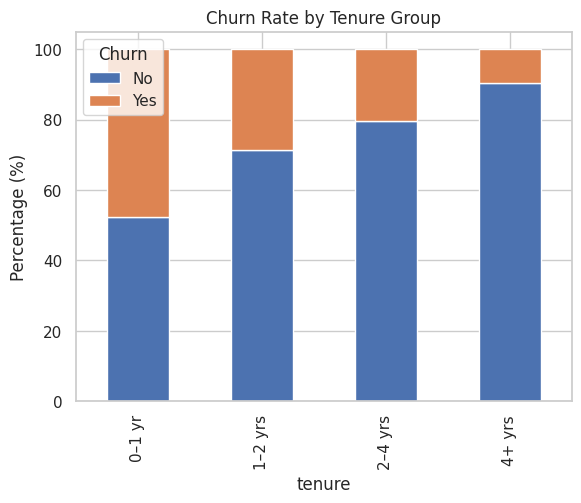

In [ ]:
#Tenure and churn connection, shown by a split histogram
#sns.histplot(data=df,x='tenure',hue='Churn') #cleaner with a stacked plot
#sns.histplot(data=df,x='tenure',hue='Churn',multiple='dodge',shrink=0.8)
tenure_bin = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–1 yr', '1–2 yrs', '2–4 yrs', '4+ yrs']
)

tenure_pct = (
    df.groupby(tenure_bin)['Churn']
      .value_counts(normalize=True)
      .unstack() * 100
)

tenure_pct.plot(kind='bar', stacked=True)
plt.ylabel('Percentage (%)')
plt.title('Churn Rate by Tenure Group')
plt.legend(title='Churn')


Added a percentaged stacked chart becuase the data generally has more seniors.

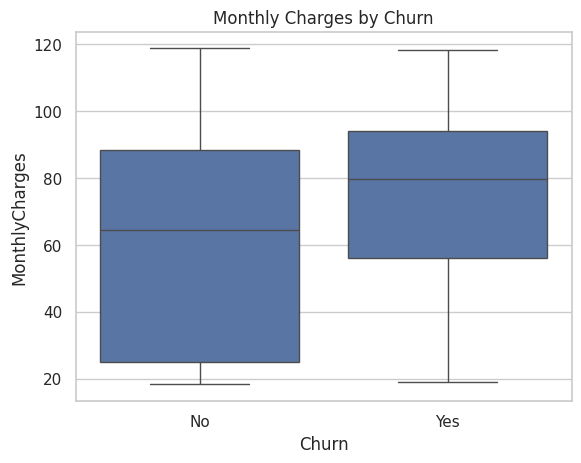

In [ ]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges by Churn")
plt.show()

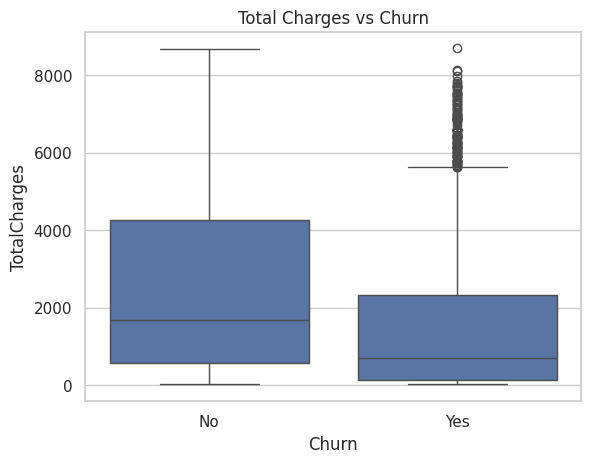

In [ ]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title("Total Charges vs Churn")
plt.show()


<Axes: xlabel='Churn', ylabel='TotalCharges'>

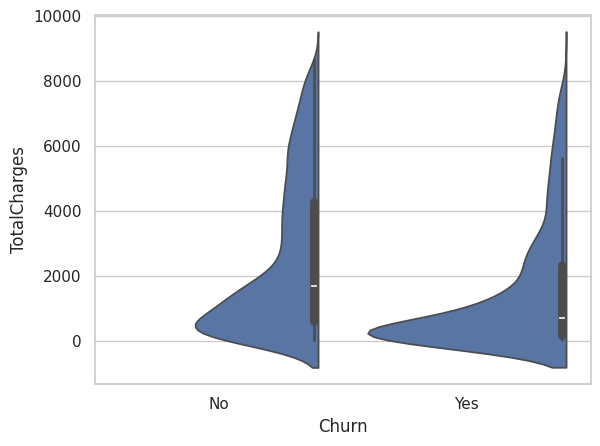

In [ ]:
# Decided for an additional violin plot becuase the box plot just looked weird (both monthly and total are there)
#sns.violinplot(data=df,x='Churn',y='MonthlyCharges',split='True')
sns.violinplot(data=df,x='Churn',y='TotalCharges',split='True')

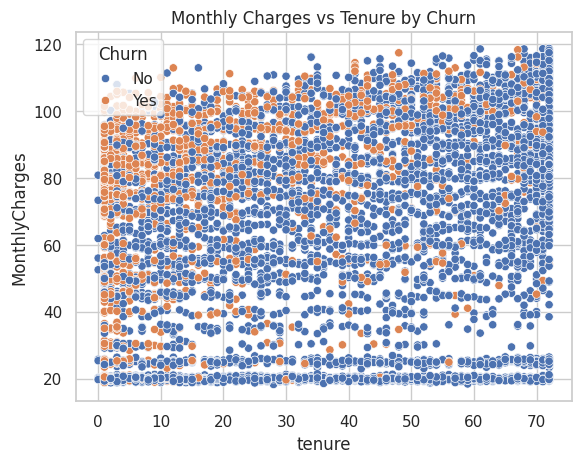

In [ ]:
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn')
plt.title("Monthly Charges vs Tenure by Churn")
plt.show()


KDE's split by Churn for Total charges and monthly charges features.

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

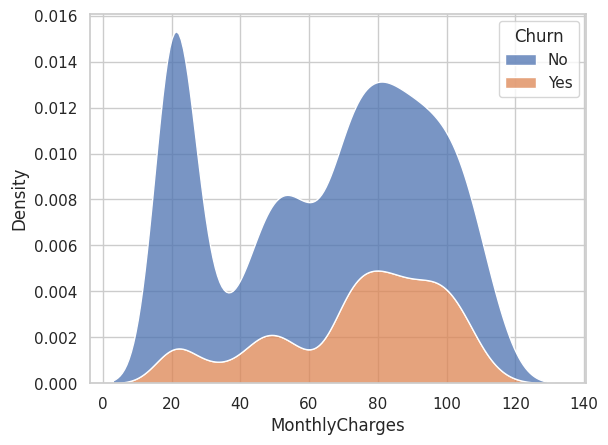

In [ ]:
#KDE's by churn for monthly charges
sns.kdeplot(data=df,x='MonthlyCharges',hue="Churn",multiple='stack')

<Axes: xlabel='TotalCharges', ylabel='Density'>

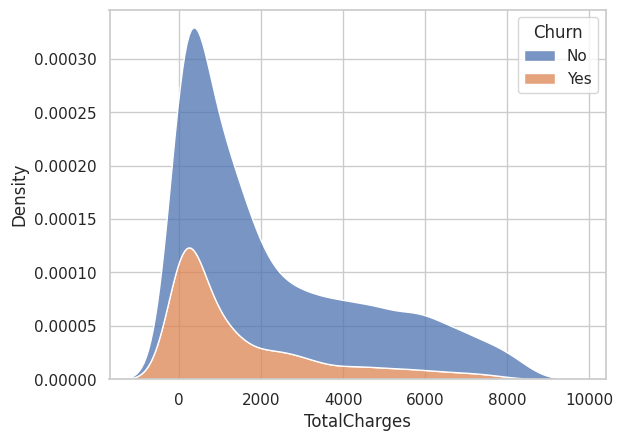

In [ ]:
#KDE's by churn for total charges
sns.kdeplot(data=df,x='TotalCharges',hue="Churn",multiple='stack')

###Feature cross-checks
Checking correlation of the numerical features agaisnt each other

<Axes: >

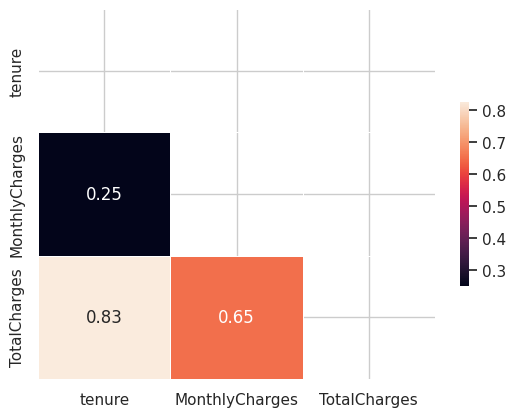

In [ ]:
#Numerical features
numerical=['tenure','MonthlyCharges','TotalCharges']

# Compute the correlation matrix
corr = df[numerical].corr()

#Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))


# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,linewidths=.5, cbar_kws={"shrink": .5},annot=True)

In [ ]:
#chi-squre test to find correlations of categoricals variables.
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

# Compute Cramér’s V matrix for all categorical columns
cat_cols = non_numeric_columns
cramers_results = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        table = pd.crosstab(df[col1], df[col2])
        cramers_results.loc[col1, col2] = cramers_v(table)

cramers_results = cramers_results.astype(float)
cramers_results


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
gender,0.999716,0.001524,0.010207,0.006008,0.009452,0.011320,0.017025,0.013798,0.006029,0.009722,0.008844,0.010641,0.008153,0.011465,0.018646
Partner,0.001524,0.999716,0.452366,0.017225,0.143898,0.000907,0.152010,0.153337,0.166568,0.127642,0.137343,0.129574,0.296039,0.014588,0.162762
Dependents,0.010207,0.452366,0.999662,0.001238,0.025094,0.180267,0.194579,0.162760,0.157570,0.182377,0.147082,0.141335,0.244212,0.111062,0.150744
PhoneService,0.006008,0.017225,0.001238,0.999188,1.000000,0.452425,0.176272,0.172818,0.172317,0.176977,0.180434,0.177520,0.003976,0.016016,0.010297
MultipleLines,0.009452,0.143898,0.025094,1.000000,1.000000,0.396726,0.229608,0.245163,0.246342,0.230162,0.261791,0.262356,0.080408,0.166341,0.166930
InternetService,0.011320,0.000907,0.180267,0.452425,0.396726,1.000000,0.724466,0.707184,0.707108,0.722904,0.717099,0.716008,0.206921,0.378427,0.313123
OnlineSecurity,0.017025,0.152010,0.194579,0.176272,0.229608,0.724466,1.000000,0.718434,0.717291,0.733071,0.707788,0.708208,0.301349,0.341800,0.304959
OnlineBackup,0.013798,0.153337,0.162760,0.172818,0.245163,0.707184,0.718434,1.000000,0.719125,0.719834,0.714699,0.713682,0.258572,0.321046,0.282517
DeviceProtection,0.006029,0.166568,0.157570,0.172317,0.246342,0.707108,0.717291,0.719125,1.000000,0.726485,0.733661,0.736047,0.296976,0.321631,0.287021
TechSupport,0.009722,0.127642,0.182377,0.176977,0.230162,0.722904,0.733071,0.719834,0.726485,1.000000,0.716266,0.716327,0.331021,0.329524,0.306888


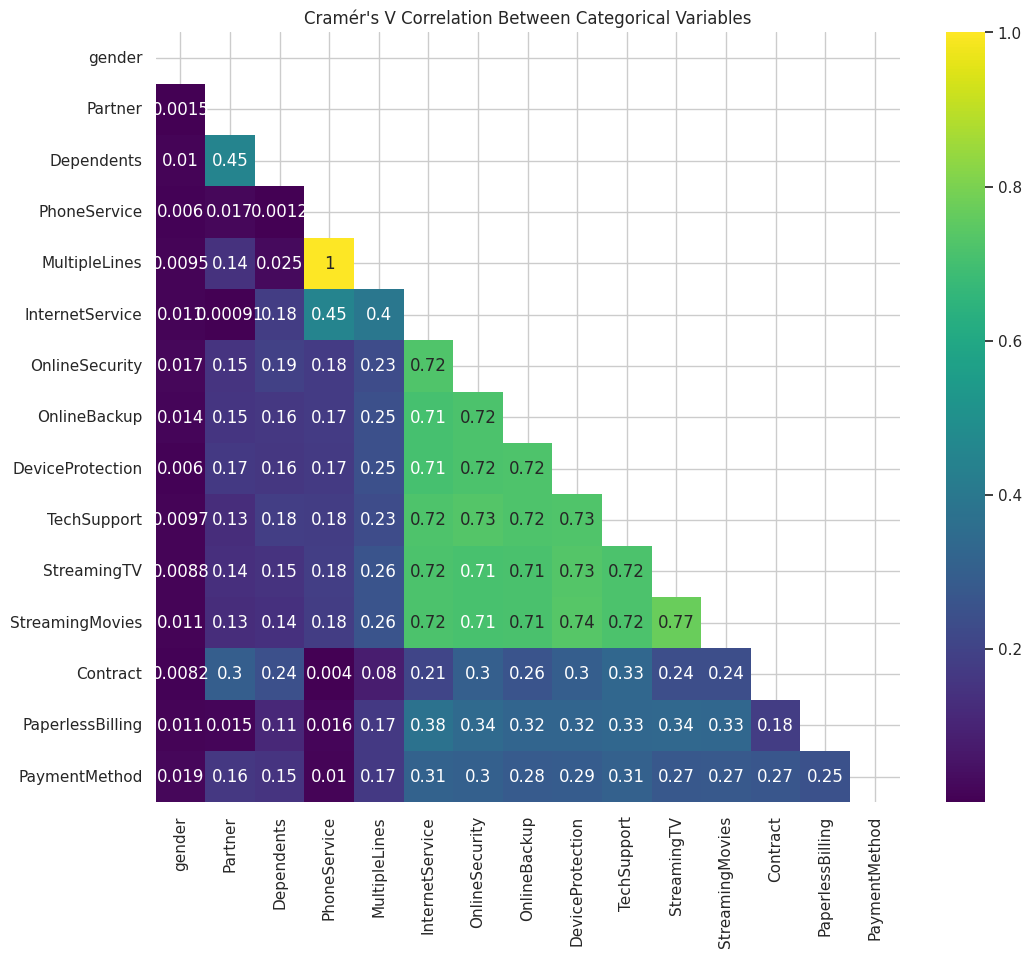

In [ ]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(cramers_results, dtype=bool))
sns.heatmap(cramers_results, annot=True, cmap='viridis',mask=mask)
plt.title("Cramér's V Correlation Between Categorical Variables")
plt.show()


### EDA insights

# Preprocessing

###Plan
* TotalCharges dtype (object -> numeric) :
  * Got 11 NaN values with 'coerce' approach.
  * Plan -> drop
  * Cannot impute with mode because there's a connection between tenure x monthlyCharges != totalChaarges in most samples and further cannot impute with median since the outliers might be affecting.
  * Since 11 records is < 0.15 % of the dataset, dropping those records will have almost to no effect on mdoel accuracy.

**What I plan to do**
* totalcharges dtype object-> numeric
* handle the totalCharges missing values
* drop irrelevant col
* handle duplicates
* handle class imblanace
* feature scaling
* handle outliers
* encode categorical features
* fix column naming
* split data




###

**What's been done**
* Made a fresh copy and added the seeds.

In [17]:
# Dataframe copy
df_prep=df_raw.copy()

In [18]:
#setting global seeds for easy access
SEED= 42

#for numpy
np.random.seed(SEED)
random.seed(SEED)

#for tensorflow
tf.random.set_seed(SEED)



In [19]:
df_prep.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [20]:
# Convert the totalCharges column to numeric and morphing it to the dataset
df_prep['TotalCharges'] = pd.to_numeric(df_prep['TotalCharges'], errors='coerce')


In [21]:
# Checking the percentage of the missing records
percent=(df_prep.isna().sum())
percent

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [22]:
df_prep.isna().sum() #11 NaN values after type conversion

#Remove the 11 rows from the data set since <1% and the effect is negligible.
df_prep=df_prep.dropna(subset=['TotalCharges'])

#remove confirmation
df_prep.isna().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Handling outliers**
* IQR method will be used.

In [23]:
def outlier_summary(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

# Call it with column names
for col in ['MonthlyCharges','tenure','TotalCharges']:
    print(f'{col} = {outlier_summary(col)}')

MonthlyCharges = 0
tenure = 0
TotalCharges = 0


Since there are no outliers visible, preprocessing was continued without any changes made for outliers.

In [24]:
# Checking for duplicates
df_prep.duplicated().sum()

np.int64(0)

The above test proved there are no duplicates in the dataset therefore no steps to manipulate the data was taken and preprocessing is continued.

Dropping irrelavant columns.
* Since the customerID is irrelavant for the modelling phase, the decision was taken to drop the column from the dataset as a step in feature engineering.

In [25]:
#Dropping the customer ID column
df_prep=df_prep.drop(columns=['customerID'])

#confirmation for column drop
df_prep.shape #nee df has 20 columns instead of the 21 original columns

(7032, 20)

**Tranform the column names to have consistent naming**

Since the dataset's column names follow multiple cases of snake case and camel case, the columns were transformed to have snake case so that it follows anming conventions better.

In [33]:
#Renaming all the columns to have snake case
df_prep.columns

df_prep=df_prep.rename(columns={'gender':"gender",
                   'SeniorCitizen':"senior_citizen",
                   'Partner':"partner",
                   'Dependents':"dependants",
                   'tenure':"tenure",
                  'PhoneService':"phone_service",
                   'MultipleLines':"multiple_lines",
                   'InternetService':"internet_service",
                   'OnlineSecurity':"online_security",
                  'OnlineBackup':"online_backup",
                   'DeviceProtection':"device_protection",
                   'TechSupport':"tech_support",
                   'StreamingTV':"streaming_tv",
                  'StreamingMovies':"streaming_movies",
                   'Contract':"contract",
                   'PaperlessBilling':"paperless_billing",
                   'PaymentMethod':"payment_method",
                  'MonthlyCharges':"monthly_charges",
                   'TotalCharges':"total_charges",
                   'Churn':"churn"
                   }
          , errors="raise")

df_prep

,gender,senior_citizen,partner,dependants,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


**Encode categorical features**

Even though the decision tree can take non-numerical data, when training the neural network it won't work without numerical data, therefore the categorical columns are converted into numerics.

In the categorical columns, the multi-class features will use one-hot encoding and the binary features will be mapped.

In [34]:
df_prep.dtypes

,0
gender,object
senior_citizen,int64
partner,object
dependants,object
tenure,int64
phone_service,object
multiple_lines,object
internet_service,object
online_security,object
online_backup,object


Since senior_citizen column is of dtype int64, but logically is a categorical column, the dtype was converted to object type since it will then be good for encoding.

In [38]:
#converting the dtype of senior_citizen
df_prep['senior_citizen'] = df_prep['senior_citizen'].astype('category')
df_prep['senior_citizen'].dtypes

CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64)

**Encoding and Scaling**

For scaling the categorical features, one hot encoding for all columns are used since the column count is not large.

For scaling, min max normalization is used for the numerical cloumns since all the columns are of positive values, roughly bounded , contains no outliers.

Breaking the traget and features for encoding to make sure there is no leakage when encoding. And binary mapping was done separately for the tagret since OHE might prove to be an overkill.


In [49]:
#Splitting the features and columns
# mapped the target since it's more easier

X= df_prep.drop('churn', axis=1)
y=df_prep['churn'].map({'No':0, 'Yes':1})
